___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Keras-RL DQN Model


## Introduction to keras-rl(2)

In this notebook we will create our first Reinforcement Learning agent via keras-rl together,
based on a simple task from open-ai gym, namely the *Cartpole Example*

https://github.com/keras-rl/keras-rl/tree/master <br>
https://keras-rl.readthedocs.io/en/latest/

At first we will import all necessary packages:

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import gymnasium as gym

In [3]:
import time

In [4]:
from pyglet.window import key

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Activation , Flatten
from tensorflow.keras.optimizers import Adam

In [6]:
import matplotlib.pyplot as plt

In [7]:
%config InlineBackened.figure_format = "retina"

In [8]:
import rl

In [9]:
#print(rl.__file__)

In [10]:
from rl.agents.dqn import DQNAgent

In [11]:
env_name = "CartPole-v1"

In [12]:
env = gym.make(id =env_name)
env.action_space.n

2

In [13]:
env = gym.make(id =env_name , render_mode = "human")
state , info = env.reset()

for _ in range(100):
    env.render()
    action = env.action_space.sample()
    env.step(action)

env.close()

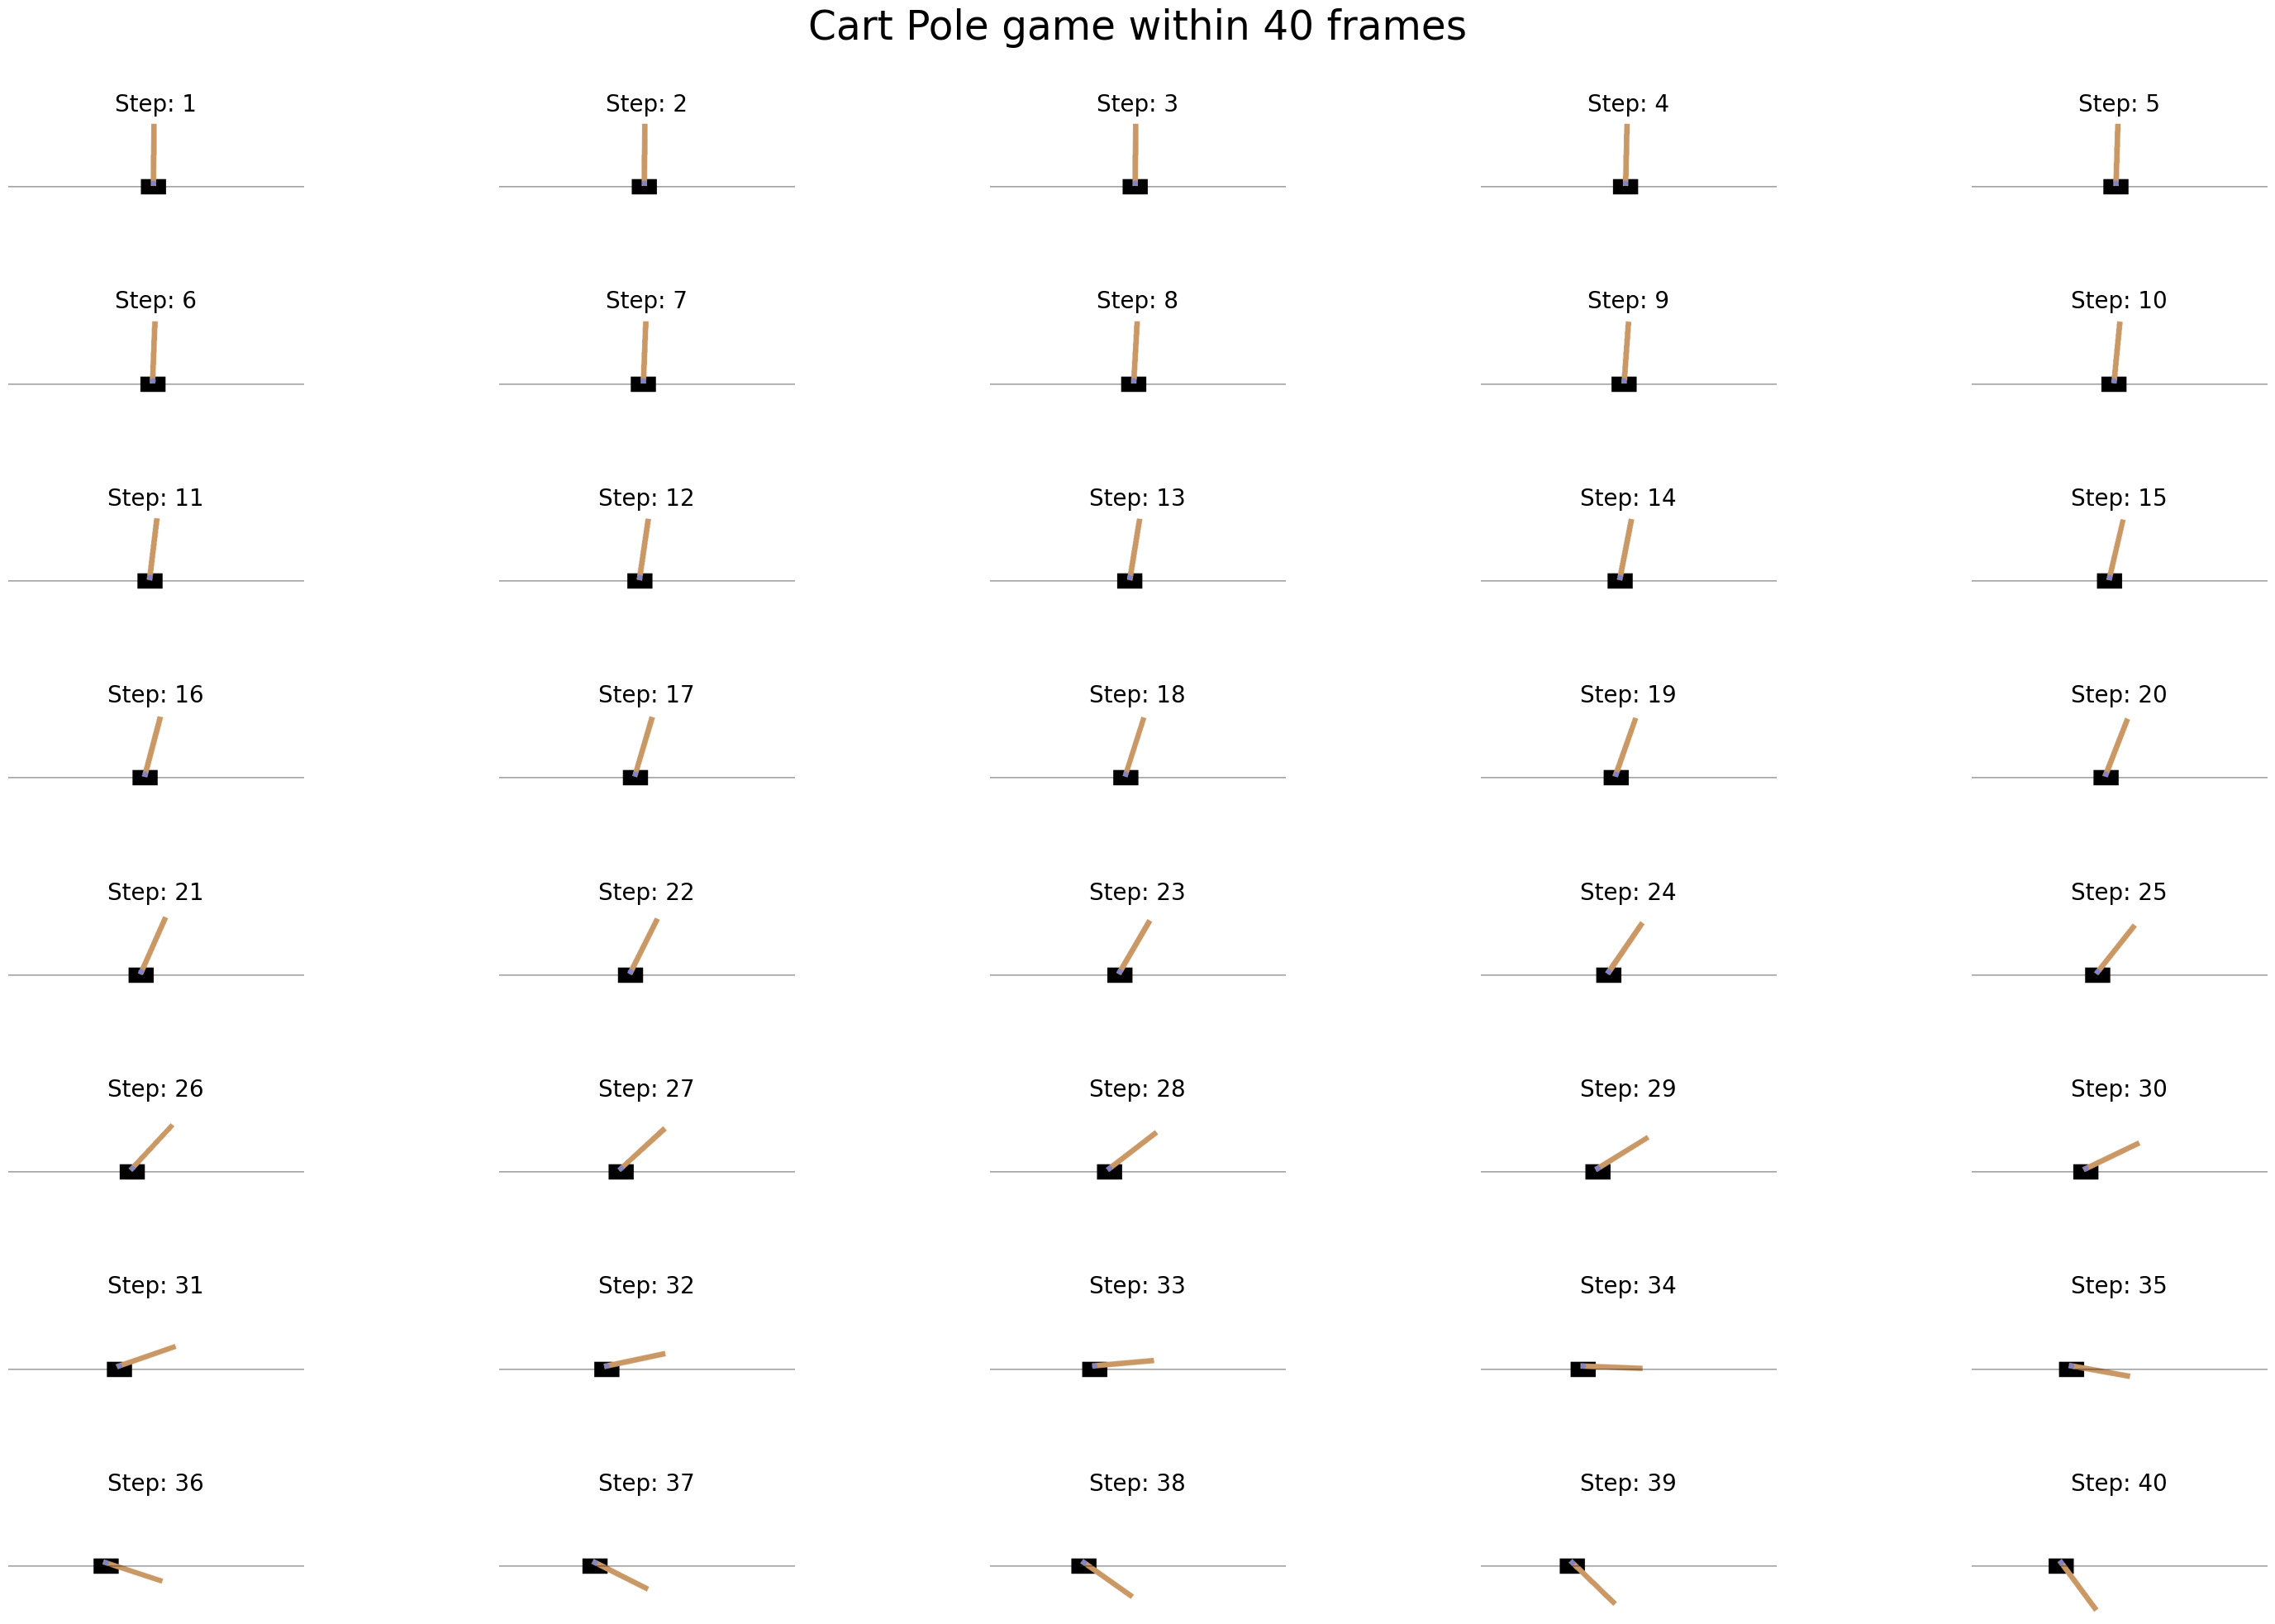

In [14]:
env = gym.make(id = env_name , render_mode = "rgb_array")

state , info = env.reset()
fig , ax = plt.subplots(figsize = (30,20) , nrows = 8 , ncols = 5, constrained_layout = True , sharex = "all" , sharey =  "all")
ax_flat = ax.flatten()

for i in range(40):
    frame = env.render()
    action = env.action_space.sample()
    stae , reward , truncated , terminated , info = env.step(action)
    
    ax_flat[i].imshow(frame)
    ax_flat[i].set_title(f"Step: {i+1}" , y = 0.6 , fontsize = 20)
    ax_flat[i].axis("off")

fig.suptitle(t = "Cart Pole game within 40 frames", fontsize = 35)
fig.tight_layout()
fig.subplots_adjust(hspace=0.001 , wspace= .00001)
plt.show()
env.close()

Now we will create the environment:

Lets watch how the game looks when chosing random actions, or to be precise randomly move left and right

In [15]:
# env.reset()  # reset the environment to the initial state
# for _ in range(200):  # play for max 200 iterations
#     env.render(mode="human")  # render the current game state on your screen
#     random_action = env.action_space.sample()  # chose a random action
#     env.step(random_action)  # execute that action
# env.close()  # close the environment

Now it is time that you try your luck! Try it out by using the left and right arrow key

In [16]:
# action = 0
# def key_press(k, mod):
#     '''
#     This function gets the key press for gym
#     '''
#     global action
#     if k == key.LEFT:
#         action = 0
#     if k == key.RIGHT:
#         action = 1

# env.reset()
# rewards = 0
# for _ in range(1000):
#     env.render(mode="human")
#     env.viewer.window.on_key_press = key_press  # update the key press
#     observation, reward, done, info = env.step(action)
#     rewards+=1
#     if done:
#         print(f"You got {rewards} points!")
#         break
#     time.sleep(0.1)  # reduce speed a little bit
# env.close()


Let us build a Deep Neural Network and try if it can beat our score

We use the same simple model with 2 hidden layers with 16 and 32 neurons each followed by relu activation

The output layer has 2 nodes, one for each action

Lets create the DQN agent from keras-rl
For this setting, the agent takes the following parameters:

1. model = The model
2. nb_actions = The number of actions (2 in this case)
3. memory = The action replay memory. You can choose between the *SequentialMemory()* and *EpisodeParameterMemory() which is only used for one RL agent called CEM*
4. nb_steps_warmup = How many iterations without training - Used to fill the memory
5. target_model_update = When do we update the target model?
6. Action Selection policy. You can choose between a *LinearAnnealedPolicy()*, *SoftmaxPolicy()*, *EpsGreedyQPolicy()*, *GreedyQPolicy()*, *GreedyQPolicy()*, *MaxBoltzmannQPolicy()* and *BoltzmannGumbelQPolicy()*. We use all of them during the next notebooks but feel free to try them out and inspect which works best here

There are some more parameters, you can pass to the DQN Agent. Feel free to explore them, but we will also take a look at them together in the remaining notebooks

Here we initialize the circular buffer with a limit of 20000 and a window length of 1.
The window length describes the number of subsequent actions stored for a state.
This will be demonstrated in the next lecture, when we start dealing with images


In [29]:
class OldAPIWrapper(gym.Env):
    def __init__(self, env):
        self.env = env
        self.observation_space = env.observation_space
        self.action_space = env.action_space

    def reset(self):
        obs, info = self.env.reset()
        return obs  # return only obs, not the tuple

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return obs, reward, done, info 

    def render(self , mode = "human"):
        return self.env.render()

    def close(self):
        return self.env.close()

In [30]:
env = OldAPIWrapper(gym.make(env_name))  

In [31]:
nb_actions = env.action_space.n


In [32]:
obs = env.reset()
nb_obs = obs.shape 

In [33]:
nb_obs

(4,)

In [34]:
from tensorflow.keras.layers import Flatten

model = Sequential()
# We tell the model: expect (1 timestep, N features), then Flatten removes the 1
model.add(Flatten(input_shape=(1, nb_obs[0]))) 
model.add(Dense(16))
model.add(Activation("relu"))
model.add(Dense(32))
model.add(Activation("relu"))
model.add(Dense(nb_actions))
model.add(Activation("linear"))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 4)                 0         
                                                                 
 dense_3 (Dense)             (None, 16)                80        
                                                                 
 activation_3 (Activation)   (None, 16)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                544       
                                                                 
 activation_4 (Activation)   (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 2)                 66        
                                                                 
 activation_5 (Activation)   (None, 2)                

In [35]:
# import numpy as np

# def reset(self):
#     # ... your reset logic ...
#     state = (value1, value2, value3, value4)  # currently returns tuple
#     return np.array(state, dtype=np.float32)  # ✅ convert to array

# def step(self, action):
#     # ... your step logic ...
#     next_state = (v1, v2, v3, v4)  # currently returns tuple
#     return np.array(next_state, dtype=np.float32), reward, done, info

In [36]:
from rl.memory import SequentialMemory
memory = SequentialMemory(limit=50000, 
                          window_length=1, 
                          #ignore_episode_boundaries=False
                         )

Then we define the Action Selection Policy: <br />
We use *LinearAnnealedPolicy* in order to perform the epsilon greedy strategy with decaying epsilon. <br />
*LinearAnnealedPolicy* accepts an action selection policy, its maximal and minimal values and a step number in order to create a dynimal policy. <br/>
The minimal value epsilon can reach during training is 0.1.<br />
For evaluation (e.g running the agent) it is fixed to 0.05


In [37]:
# LinearAnnealedPolicy allows to decay the epsilon for the epsilon greedy strategy
from rl.policy import LinearAnnealedPolicy, EpsGreedyQPolicy

policy = LinearAnnealedPolicy(inner_policy = EpsGreedyQPolicy(), 
                              attr='eps',
                              value_max = 1,
                              value_min = 0.1,
                              value_test = 0.05,
                              nb_steps = 20000)

Now we create the DQN Agent based on the defined model (**model**), the possible actions (**nb_actions**) (left and right in this case), the circular buffer (**memory**), the burnin or warmup phase (**10**), how often the target model gets updated (**100**) and the policy (**policy**)


In [38]:
dqn = DQNAgent(model = model,
               nb_actions = nb_actions,
               memory = memory,
               nb_steps_warmup = 10,
               target_model_update = 100,
               policy = policy
              )

Finally we compile our model with the Adam optimizer and a learning rate of 0.001.<br />
We log the Mean Absolute Error

In [39]:
# Use learning_rate instead of lr if you get warning
dqn.compile(optimizer = Adam(learning_rate = 1e-3) , metrics = ["mae"])

Now we run the training for 20000 steps. You can change visualize=True if you want to watch your model learning.
Keep in mind that this increases the running time
The training time is around 5 min so grep your favorite beverage and stay tuned


In [44]:
dqn.fit(env, 
        nb_steps = 20000, 
        visualize = False, 
        verbose = 2)

Training for 20000 steps ...
    12/20000: episode: 1, duration: 0.765s, episode steps:  12, steps per second:  16, episode reward: 12.000, mean reward:  1.000 [ 1.000,  1.000], mean action: 0.250 [0.000, 1.000],  loss: 18.592594, mae: 85.847252, mean_q: 178.657578, mean_eps: 0.999505
    26/20000: episode: 2, duration: 0.310s, episode steps:  14, steps per second:  45, episode reward: 14.000, mean reward:  1.000 [ 1.000,  1.000], mean action: 0.714 [0.000, 1.000],  loss: 12.853855, mae: 92.643609, mean_q: 189.888453, mean_eps: 0.999168
    46/20000: episode: 3, duration: 0.432s, episode steps:  20, steps per second:  46, episode reward: 20.000, mean reward:  1.000 [ 1.000,  1.000], mean action: 0.650 [0.000, 1.000],  loss: 24.973755, mae: 93.846533, mean_q: 190.858216, mean_eps: 0.998403
    63/20000: episode: 4, duration: 0.365s, episode steps:  17, steps per second:  47, episode reward: 17.000, mean reward:  1.000 [ 1.000,  1.000], mean action: 0.529 [0.000, 1.000],  loss: 46.904633

Wow! After only some minutes of training, we achieve great results!
The reason for this is, that keras-rl has implemented many optimization strategies (e.g the optimized replay buffer) which lead to a much faster convergence than our DQN implemented by hand

In [47]:
# After training is done, we save the final weights.
dqn.save_weights(f'dqn_{env_name}_weights.h5f', overwrite=True)

In [45]:
env = OldAPIWrapper(gym.make(env_name, render_mode="human"))

In [46]:
# Finally, evaluate our algorithm for 5 episodes.
dqn.test(env, nb_episodes=5, visualize=True)
env.close()

Testing for 5 episodes ...
Episode 1: reward: 227.000, steps: 227
Episode 2: reward: 225.000, steps: 225
Episode 3: reward: 247.000, steps: 247
Episode 4: reward: 240.000, steps: 240
Episode 5: reward: 227.000, steps: 227
